#### Aula 2 - Abrindo e acessando informações de imagens de Sensoriamento Remoto

#### 1.  Como abrir imagens utilizando a biblioteca `rasterio`?

Atualmente, existem várias bibliotecas em Python que nos permite acessar diversos tipos de arquivos raster utilizados em SIG. Uma delas, o rasterio, é uma biblioteca de alto desempenho construída a partir do GDAL (Geospatial Data Abstraction Library) que permite códigos mais limpos e transparentes, simplificando atividades e pode ser muito poderosa quando utilizada em conjunto com outras bibliotecas como `numpy`, `pandas`, e `matplotlib`.

* Para acessar a documentação dessa biblioteca, clique no link: https://rasterio.readthedocs.io/en/stable/index.html 
* Repositório do rasterio no PyPI: https://pypi.org/project/rasterio/


In [3]:
# A instalação do rasterio pode ser feita a partir do comando: 
# pip install rasterio 
# conda install rasterio
# (ou !pip install rasterio em ambientes como google colab)

Importando o rasterio

In [1]:
import rasterio

Abrindo um arquivo raster com o método `rasterio.open()`.

In [2]:
# Primeiramente, precisamos informar o caminho para o arquivo:

image_path = 'G:/Meu Drive/UNIFESP/forest_eyes/4.imagens/imagens_processadas/data_sbsr/processamento_2/LANDSAT_8.TIF'

dataset = rasterio.open(image_path)

Quando rodamos apenas a célula com a variável dataset, observamos que apenas é apresentado o seu conteúdo com o tipo do dado, o nome do caminho do e do modo utilizado.
'r' representa o modo de leitura do arquivo.

In [3]:
dataset

<open DatasetReader name='G:/Meu Drive/UNIFESP/forest_eyes/4.imagens/imagens_processadas/data_sbsr/processamento_2/LANDSAT_8.TIF' mode='r'>

Podemos usar o método `.meta` para observar algujns metadados da imagem...

In [4]:
dataset.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': 0.0,
 'width': 1230,
 'height': 843,
 'count': 6,
 'crs': CRS.from_wkt('PROJCS["SIRGAS 2000 / UTM zone 22S",GEOGCS["SIRGAS 2000",DATUM["Sistema_de_Referencia_Geocentrico_para_las_AmericaS_2000",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6674"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4674"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-51],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","31982"]]'),
 'transform': Affine(29.999999999503903, 0.0, 203624.99999843573,
        0.0, -29.999999999503903, 9384205.000018748)}

O objeto DatasetReader possui vários atributos e métodos associados. Eles podem ser listados por meio da função dir(). Alguns desses atributos são especiais e fogem do escopo da aula, por isso utilizaremos um filtro para mostrar apenas os atributos normais.

In [5]:
atributos = [attr for attr in dir(dataset) if not attr.startswith('_')]
print(atributos)

['block_shapes', 'block_size', 'block_window', 'block_windows', 'bounds', 'checksum', 'close', 'closed', 'colorinterp', 'colormap', 'compression', 'count', 'crs', 'dataset_mask', 'descriptions', 'driver', 'dtypes', 'files', 'gcps', 'get_gcps', 'get_nodatavals', 'get_tag_item', 'get_transform', 'height', 'index', 'indexes', 'interleaving', 'is_tiled', 'lnglat', 'mask_flag_enums', 'meta', 'mode', 'name', 'nodata', 'nodatavals', 'offsets', 'options', 'overviews', 'photometric', 'profile', 'read', 'read_crs', 'read_masks', 'read_transform', 'res', 'rpcs', 'sample', 'scales', 'shape', 'start', 'statistics', 'stats', 'stop', 'subdatasets', 'tag_namespaces', 'tags', 'transform', 'units', 'width', 'window', 'window_bounds', 'window_transform', 'write_transform', 'xy']


Observando alguns atributos:

In [6]:
print('ATRIBUTOS:\n')
print(f' >> Nome do arquivo: {dataset.name}\n')
print(f' >> Modo: {dataset.mode}\n')
print(f' >> Contagem de bandas: {dataset.count}\n')
print(f' >> Largura x Altura: {dataset.width}x{dataset.height}\n')
print(f' >> Limites geográficos: {dataset.bounds}\n')
print(f' >> Transformação Afim: \n{dataset.transform}\n')
print(f' >> Resolução espacial: {dataset.res}\n')
print(f' >> Tipos dos dados: {dataset.dtypes}\n')
print(f' >> Sistema Geodésico de Referência: {dataset.crs}\n')

ATRIBUTOS:

 >> Nome do arquivo: G:/Meu Drive/UNIFESP/forest_eyes/4.imagens/imagens_processadas/data_sbsr/processamento_2/LANDSAT_8.TIF

 >> Modo: r

 >> Contagem de bandas: 6

 >> Largura x Altura: 1230x843

 >> Limites geográficos: BoundingBox(left=203624.99999843573, bottom=9358915.000019167, right=240524.99999782554, top=9384205.000018748)

 >> Transformação Afim: 
| 30.00, 0.00, 203625.00|
| 0.00,-30.00, 9384205.00|
| 0.00, 0.00, 1.00|

 >> Resolução espacial: (29.999999999503903, 29.999999999503903)

 >> Tipos dos dados: ('float32', 'float32', 'float32', 'float32', 'float32', 'float32')

 >> Sistema Geodésico de Referência: EPSG:31982



Lendo uma imagem:

In [7]:
dataset.count

6

In [8]:
# Os índices das bandas podem ser acessados com o método .indexes

n_bandas = dataset.indexes
print(n_bandas)

(1, 2, 3, 4, 5, 6)


Para este exemplo a sequência de bandas foi pré-determinada como BLUE, GREEN, RED, NIR,SWIR1 e SWIR2. É importante estar atento a sequência de bandas da sua imagem para não ter problemas com as operações. Perceba que o indexing do rasterio começa em 1 e não em 0 como geralmente ocorre no python.

In [9]:
# Acessando balores da banda 1 

blue = dataset.read(1)
blue

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.0159025 , 0.01716749, 0.01727749, ..., 0.01628751, 0.01637   ,
        0.0157375 ],
       [0.017195  , 0.01738749, 0.01683749, ..., 0.0157375 , 0.01672749,
        0.01733249],
       ...,
       [0.01692   , 0.0159025 , 0.01477499, ..., 0.01846001, 0.018295  ,
        0.01648   ],
       [0.01889999, 0.0178    , 0.01639751, ..., 0.0167    , 0.01659   ,
        0.01700249],
       [0.01889999, 0.0204125 , 0.017415  , ..., 0.01482999, 0.01455499,
        0.01532499]], shape=(843, 1230), dtype=float32)

Se tentarmos acessar o índice 0, teremos `IndexError`.. Ou seja, o valor especificado está fora do range de índices existente.

In [10]:
dataset.read()

array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.0159025 , 0.01716749, 0.01727749, ..., 0.01628751,
         0.01637   , 0.0157375 ],
        [0.017195  , 0.01738749, 0.01683749, ..., 0.0157375 ,
         0.01672749, 0.01733249],
        ...,
        [0.01692   , 0.0159025 , 0.01477499, ..., 0.01846001,
         0.018295  , 0.01648   ],
        [0.01889999, 0.0178    , 0.01639751, ..., 0.0167    ,
         0.01659   , 0.01700249],
        [0.01889999, 0.0204125 , 0.017415  , ..., 0.01482999,
         0.01455499, 0.01532499]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.03058749, 0.03867249, 0.03633499, ..., 0.0360325 ,
         0.03441   , 0.0324575 ],
        [0.035785  , 0.0361425 , 0.0368025 , ..., 0.03394251,
         0.03562   , 0.0363625 ],
        ...,
        [0.0379575 , 0.038755  , 0.03454749, ..., 0.04931501,
         0.04796749, 0.04356749],
        [0.0

In [9]:
dataset.read(0)

IndexError: band index 0 out of range (not in (1, 2, 3, 4, 5, 6))

O método .open abre a imagem enquanto que o .read lê. O problema é que podemos estar ocupando espaço de memória, principalmente se estamos abrindo muitos arquivos diferentes.
Observe no comando abaixo que a imagem continua aberta, mesmo depois de lida e associada a uma variável.

In [16]:
dataset.closed

False

Podemos utilizar o método close() para fechar o arquivo, ou utilizar outra maneira de abrir a imagem.

In [17]:
dataset.close()

In [18]:
dataset.closed

True

In [19]:
# Como fechar imagens instantaneamente 
with rasterio.open(image_path) as qualquer_coisa:
    bands = qualquer_coisa.read()

In [25]:
bands.shape

(6, 843, 1230)

Nos blocos anteriores, utilizamos o `with`, que é uma estrutura de controle em Python chamada "context manager". O objetivo do `with` é garantir que os recursos usados (neste caso, o arquivo raster) sejam abertos e fechados automaticamente, mesmo que ocorra um erro durante o processamento. O context manager garante que, ao sair do bloco do `with`, o arquivo será fechado automaticamente, liberando memória e evitando problemas de acesso ao arquivo.

Vamos verificar agora qual o tipo de dado é atribuído a variável "bands" e a estrutura do dado.

In [26]:
print(f'Tipo de dado: {type(bands)}')
print(f'Shape: {bands.shape}')

Tipo de dado: <class 'numpy.ndarray'>
Shape: (6, 843, 1230)


A vantagem de utilizar o método `read` do Rasterio, que retorna os dados como um numpy.ndarray, é que isso permite aproveitar toda a eficiência e versatilidade do `NumPy` para manipulação de dados. Com o array `NumPy`, é possível realizar operações matemáticas e estatísticas rápidas, aplicar filtros, reamostrar, combinar bandas ou mesmo integrá-lo a bibliotecas como `SciPy`, `scikit-learn` ou `matplotlib` para análises avançadas e visualizações. Além disso, o formato estruturado do array facilita o acesso direto às bandas e pixels, permitindo trabalhar de forma intuitiva com os dados geoespaciais.

É importante lembrar que, nesse caso os dados são armazenados com a seguinte estrutura: BANDA x LINHA x COLUNA
Note que os métodos utilizados anteriormente só funcionam quando estamos utilizando um dado tipo `DatasetReader`.

#### Plotando imagens com rasterio.plot.show( )

O primeiro argumento de show() representa a fonte de dados a ser plotada. Pode ser uma das seguintes opções:

* Um objeto de conjunto de dados aberto no modo 'r'.
* Uma única banda de uma fonte, representada por uma tupla (src, band_index).
* Um numpy.ndarray, 2D ou 3D. Se o array for 3D, certifique-se de que esteja na ordem de bandas do Rasterio.

Importando funções do submódulo rasterio.plot

In [44]:
from rasterio.plot import show
import numpy as np

Visualizando uma banda e composições coloridas utilizando a função `show`:

In [45]:
# Abrindo imagem 
src = rasterio.open(image_path)
src

<open DatasetReader name='G:/Meu Drive/UNIFESP/forest_eyes/4.imagens/imagens_processadas/data_sbsr/processamento_2/LANDSAT_8.TIF' mode='r'>

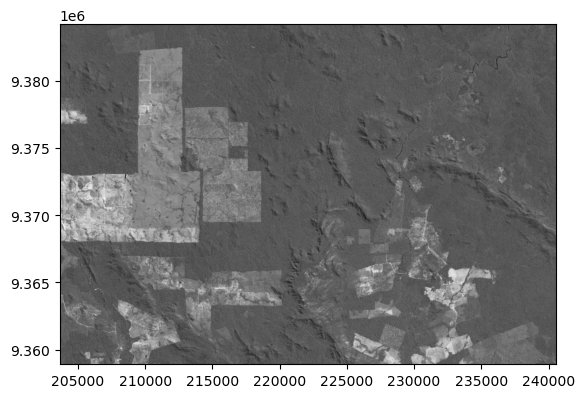

<Axes: >

In [46]:
# apresentando apenas uma banda com a paleta de cores em cinza
show((src, 5),cmap='Greys_r')

Nota: Quando utilizamos o dado em ndarray perdemos as informações e metadados da imagem. É importante salvar essa informação em processamentos. Por isso, a plotagem está sendo feita utilizando o dado no formato DatasetReader para preservar informações espaciais.

In [52]:
# Para plotar dados coloridos e com as coordenadas, precisamos primeiramente fazer um stack ou ler diretamente o dado com um dado ndarray.
with rasterio.open(image_path) as src:
    nir = src.read(4)
    red = src.read(3)
    green = src.read(2)
    blue = src.read(1)
    all = src.read()
    meta = src.meta.copy()

ABRIR IMAGEM >>> (DATASETREADER)
LER IMAGEM >>> (NUMPY_NDARRAY)

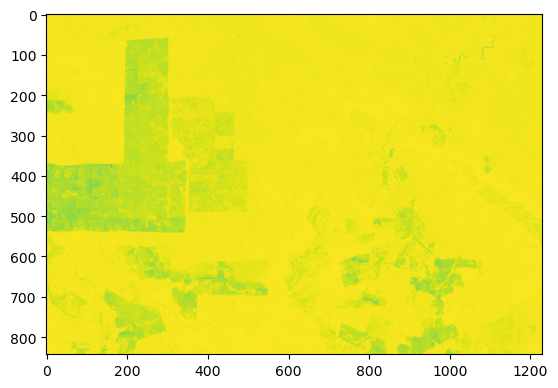

<class 'numpy.ndarray'>


In [48]:
# Exemplo NDVI
ndvi = (nir-red)/(nir + red  + 0.0000000001)
ndvi.shape
show(ndvi)
print(type(ndvi))

In [61]:
# Exemplo de composição colorida
rgb = np.stack((nir, red, green),axis=0).clip(0,1)
rgb.shape

(3, 843, 1230)

Utilizamos a função `stack` do numpy para empilhar as imagens ao longo do eixo 0. Observe que o plot não contará com as informações geográficas da imagem.

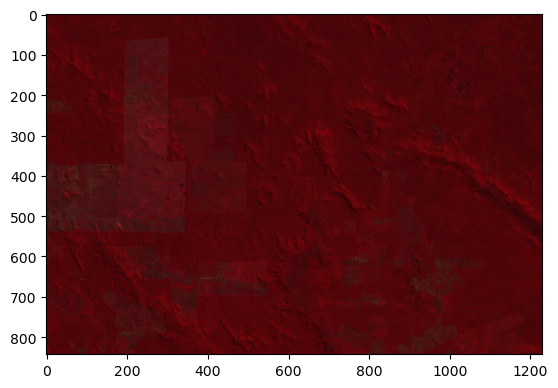

<Axes: >

In [50]:
show(rgb)

Entretanto, se for informado na função `show` os metadados referentes às posições dos pixels, é possível associar cada posição de pixel à um par de cordenadas.

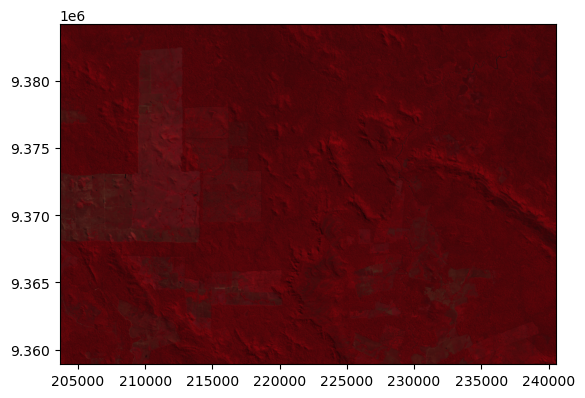

<Axes: >

In [51]:
show(rgb, transform=transform)